In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/retail-sales-dataset/retail_sales_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Loading the retail sales dataset
data_file = pd.read_csv("/kaggle/input/retail-sales-dataset/retail_sales_dataset.csv") 
data_file.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
# Displaying the dataframe information
data_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
# Overall of the descriptive statistics
data_file.describe()


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
data_file.nunique()

Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64

In [7]:
# Mean Calculation by product category over price per unit
mean_stats = data_file.groupby('Product Category')['Price per Unit'].mean()
print("Mean:", mean_stats)


Mean: Product Category
Beauty         184.055375
Clothing       174.287749
Electronics    181.900585
Name: Price per Unit, dtype: float64


In [8]:
# Mean Calculation by product category over total amount
mean_stats = data_file.groupby('Product Category')['Total Amount'].mean()
print("Mean:", mean_stats)

Mean: Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64


In [9]:
# Median Calculation by product category over price per unit
median_stats = data_file.groupby('Product Category')['Price per Unit'].median()
print("Median:", median_stats)

Median: Product Category
Beauty         50.0
Clothing       50.0
Electronics    50.0
Name: Price per Unit, dtype: float64


In [10]:
# Mean Calculation by product category over total amount
median_stats = data_file.groupby('Product Category')['Total Amount'].median()
print("Median" , median_stats)

Median Product Category
Beauty         120.0
Clothing       120.0
Electronics    150.0
Name: Total Amount, dtype: float64


In [11]:
# Mode Calculation by product category over price per unit
mode_stats = data_file.groupby('Product Category')['Price per Unit'].apply(lambda x: x.mode())
print("Mode:", mode_stats)

Mode: Product Category   
Beauty            0    500
Clothing          0     25
                  1     50
Electronics       0     25
                  1    300
Name: Price per Unit, dtype: int64


In [12]:
# Mode Calculation by product category over total amount
mode_stats = data_file.groupby('Product Category')['Total Amount'].apply(lambda x: x.mode())
print("Mode:", mode_stats)

Mode: Product Category   
Beauty            0    100
Clothing          0     50
Electronics       0     50
Name: Total Amount, dtype: int64


In [13]:
# Standard Deviation Calculation by product category over price per unit
sd_stats = data_file.groupby('Product Category')['Price per Unit'].std()
print("Standard Deviation:", sd_stats)


Standard Deviation: Product Category
Beauty         194.929399
Clothing       186.017065
Electronics    189.049673
Name: Price per Unit, dtype: float64


In [14]:
# Standard Deviation Calculation  by product category over total amount
sd_stats = data_file.groupby('Product Category')['Total Amount'].std()
print("Standard Deviation:", sd_stats)

Standard Deviation: Product Category
Beauty         563.612788
Clothing       550.695917
Electronics    567.540150
Name: Total Amount, dtype: float64


In [15]:
# Analyzing the sales trends over time 
# Retrieving and displaying the column names in the DataFrame 
column_labels = data_file.columns
print(column_labels)


Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [16]:
# Iterates the columns in the DataFrame and displays the list 
numeric_columns = []
for column_name in data_file.columns:
    if data_file[column_name].dtype != 'object':
        numeric_columns.append(column_name)

print(numeric_columns)


['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']


In [17]:
# Converts the date column in a DataFrame to datetime format with the sorted months
data_file['Date'] = pd.to_datetime(data_file['Date'])
data_file['Month'] = data_file['Date'].dt.month
sorted_months = pd.DataFrame({'Month': range(1, 13)})
data_file = pd.merge(sorted_months, data_file, on='Month', how='left')
data_file.head()


,Month,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
1,1,14,2023-01-17,CUST014,Male,64,Clothing,4,30,120
2,1,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
3,1,21,2023-01-14,CUST021,Female,50,Beauty,1,500,500
4,1,32,2023-01-04,CUST032,Male,30,Beauty,3,30,90


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


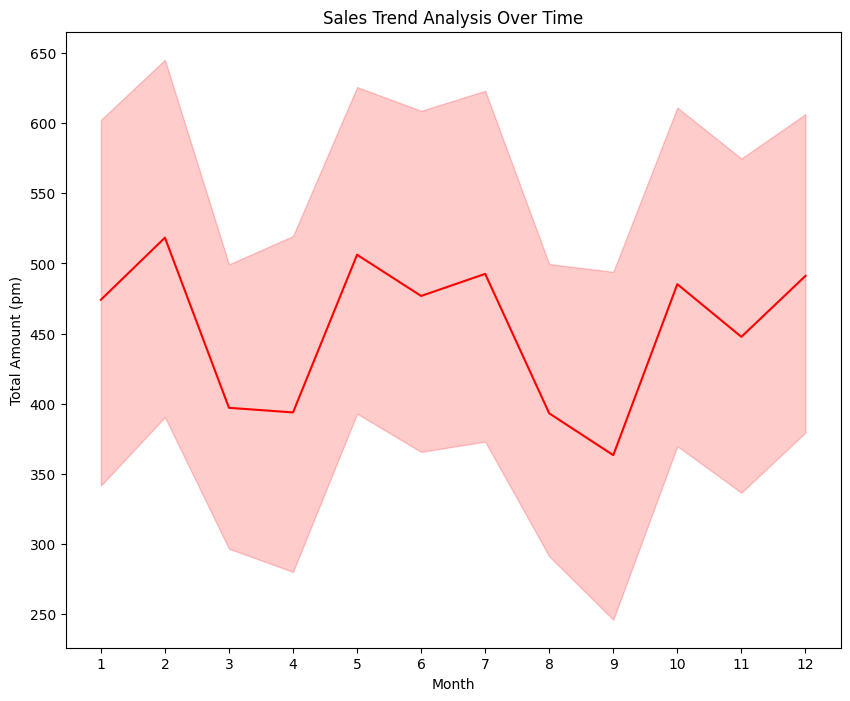

In [18]:
# Displaying the line plot graph which shows the sales trend overtime
plt.figure(figsize=(10, 8))
sns.lineplot(x ='Month', y ='Total Amount', data = data_file.sort_values('Month'), color = 'red')
plt.title('Sales Trend Analysis Over Time')
plt.xlabel('Month')
plt.ylabel('Total Amount (pm)')
plt.xticks(range(1, 13))  
plt.show()


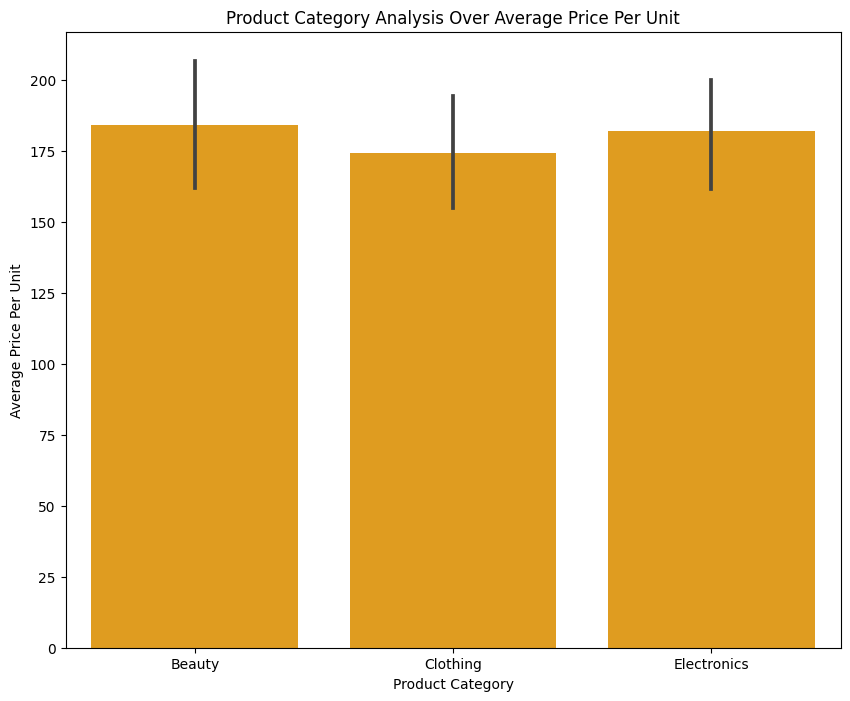

In [19]:
# Displaying the bar plot graph which shows the product category analysis over average price per unit
plt.figure(figsize=(10, 8))
sns.barplot(x ='Product Category', y ='Price per Unit', data = data_file.sort_values('Product Category'), color = 'orange')
plt.title('Product Category Analysis Over Average Price Per Unit')
plt.xlabel('Product Category')
plt.ylabel('Average Price Per Unit') 
plt.show()


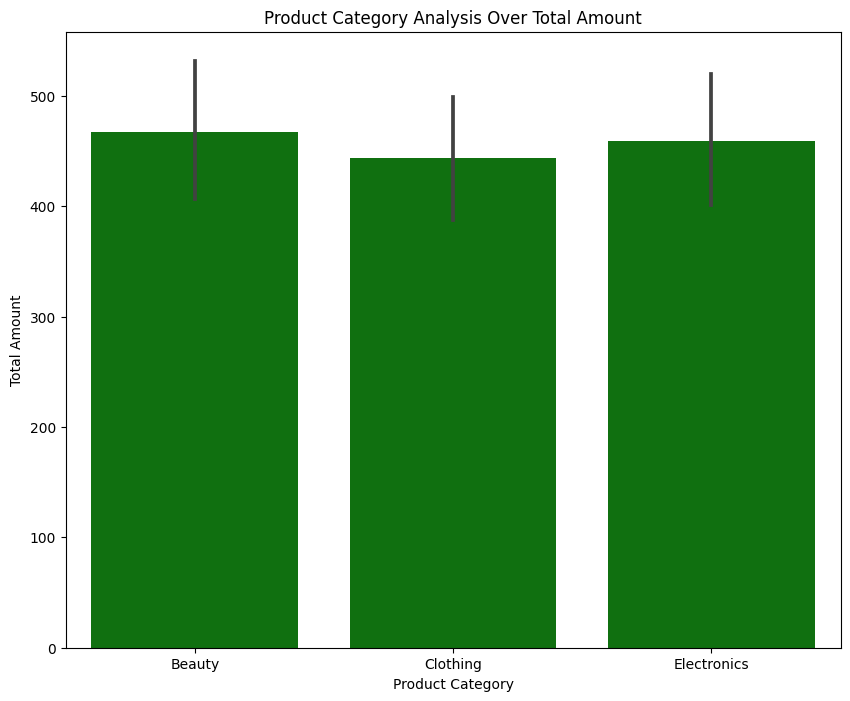

In [20]:
# Displaying the bar plot graph which shows the product category analysis over total amount
plt.figure(figsize=(10, 8))
sns.barplot(x ='Product Category', y ='Total Amount', data = data_file.sort_values('Product Category'), color = 'green')
plt.title('Product Category Analysis Over Total Amount')
plt.xlabel('Product Category')
plt.ylabel('Total Amount') 
plt.show()


In [21]:
# Retrieves the transactions per month made by the customer
data_file['Month'] = data_file['Date'].dt.month
transaction_total_amount = data_file.groupby('Month')['Transaction ID'].nunique()


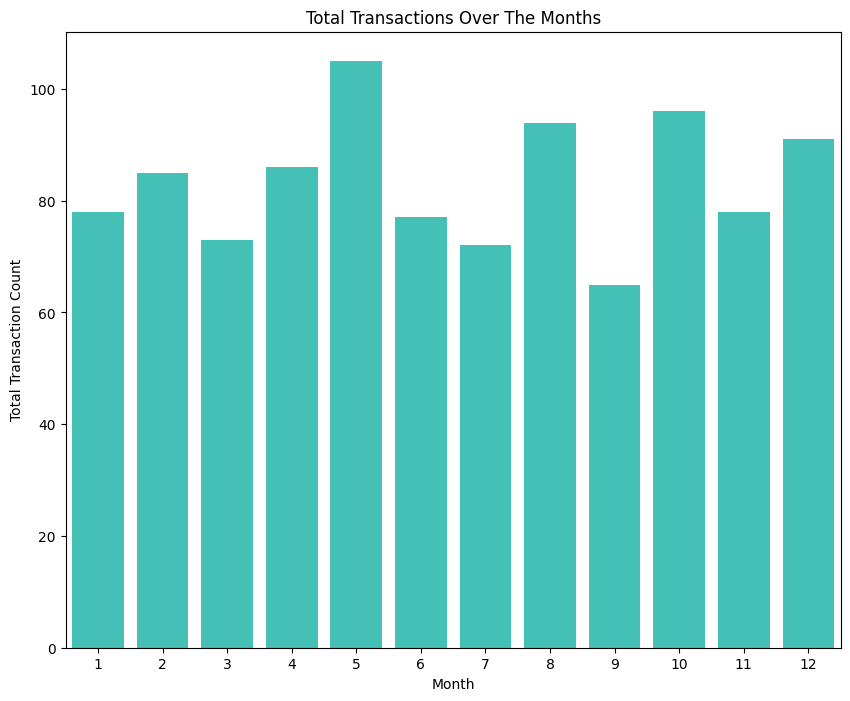

In [22]:
# Displaying the bar plot graph which shows the transaction amount over the months
plt.figure(figsize = (10, 8))
sns.barplot(x = transaction_total_amount.index, y = transaction_total_amount.values, color = '#30D5C8')
plt.title('Total Transactions Over The Months')
plt.xlabel('Month')
plt.ylabel('Total Transaction Count')
plt.show()

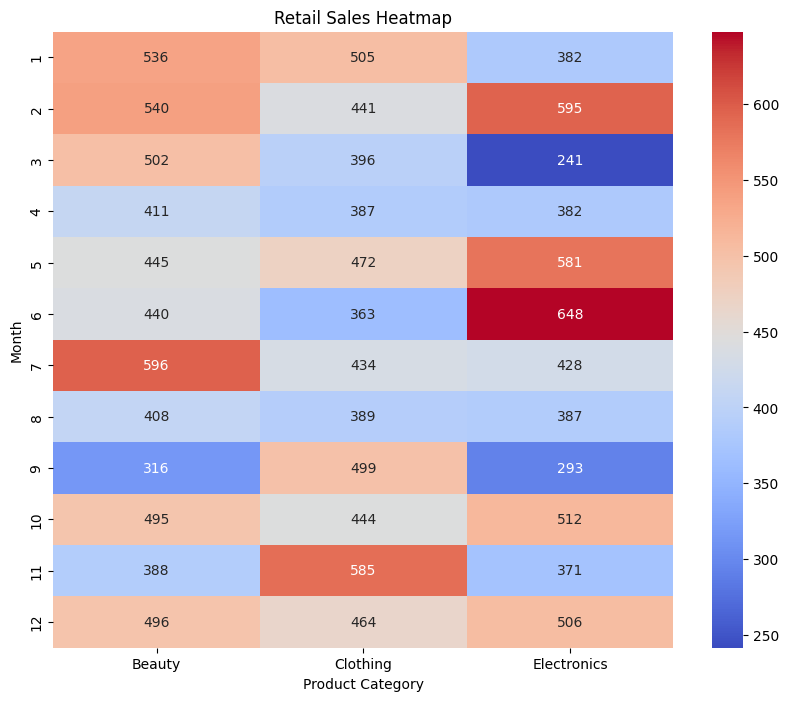

In [23]:
# Displaying the heatmap which shows the retail sales over the months
heatmap = data_file.pivot_table(index ='Month', columns = 'Product Category', values = 'Total Amount')
plt.figure(figsize = (10, 8))
sns.heatmap(heatmap, annot = True, fmt = '.0f', cmap = 'coolwarm')
plt.title('Retail Sales Heatmap')
plt.xlabel('Product Category')
plt.ylabel('Month')
plt.show()

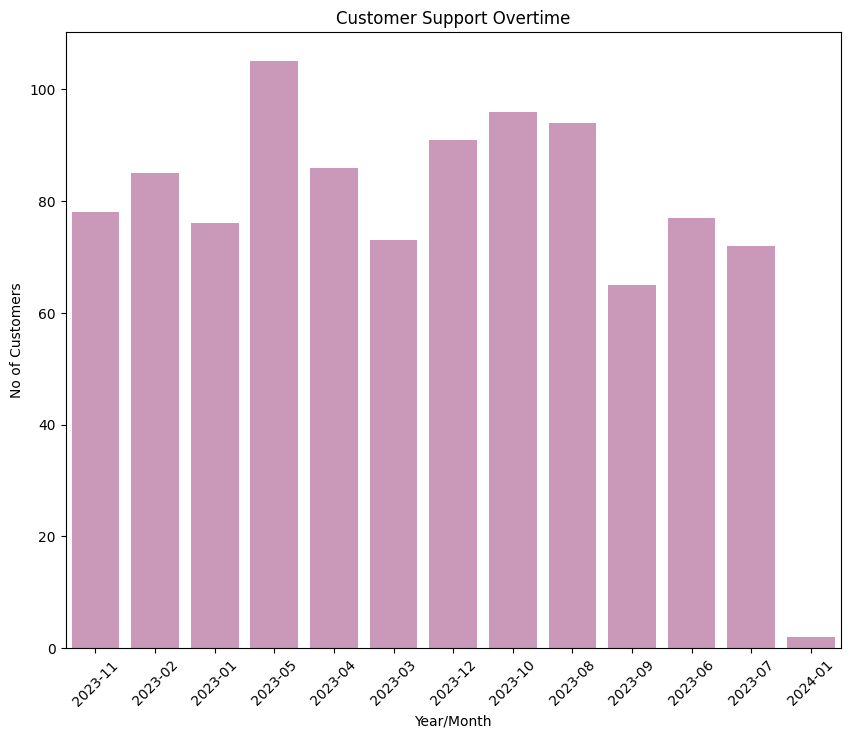

In [24]:
# Displaying the bar plot graph which shows customer support overtime
support = data_file.groupby('Customer ID')['Date'].min().reset_index()
support['Year/Month'] = support['Date'].dt.to_period('M')

plt.figure(figsize = (10, 8))
sns.countplot(x = 'Year/Month', data = support, color = '#D291BC')
plt.title('Customer Support Overtime')
plt.xlabel('Year/Month')
plt.ylabel('No of Customers')
plt.xticks(rotation = 45) 
plt.show()

In [25]:
# Defining and displaying the few rows of the DataFrame 
data_file['Age'] = pd.to_numeric(data_file['Age'], errors = 'coerce')
age_bins = [0, 18, 25, 35, 50, 100]
age_labels = ['0-18', '19-25', '26-35', '36-50', '50+']
data_file['Age Group'] = pd.cut(data_file['Age'], bins = age_bins, labels = age_labels)
data_file.head()

,Month,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group
0,1,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,36-50
1,1,14,2023-01-17,CUST014,Male,64,Clothing,4,30,120,50+
2,1,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000,36-50
3,1,21,2023-01-14,CUST021,Female,50,Beauty,1,500,500,36-50
4,1,32,2023-01-04,CUST032,Male,30,Beauty,3,30,90,26-35


/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


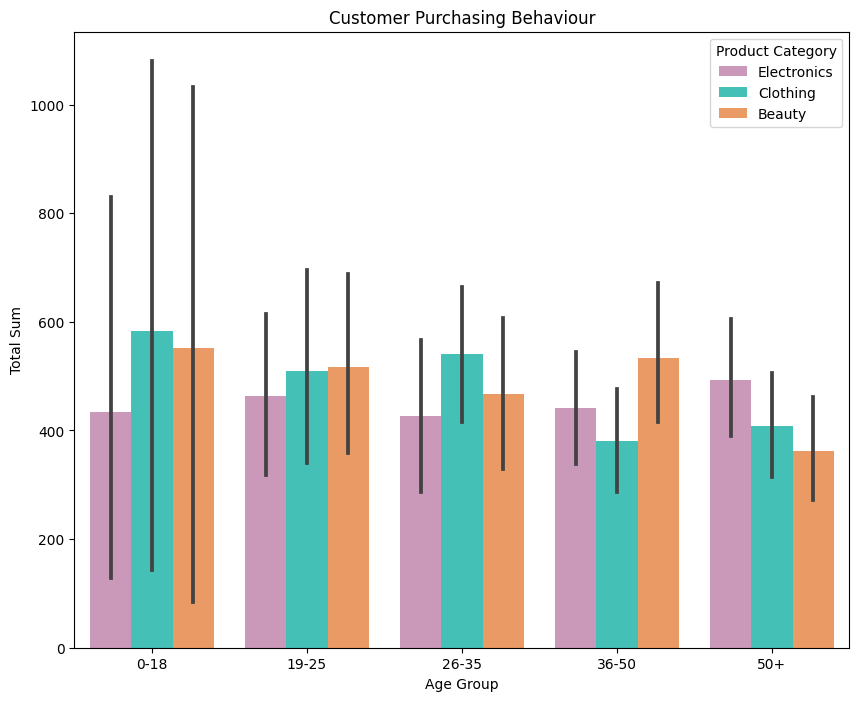

In [26]:
# Displaying the bar plot graph which shows customer purchasing behaviour
plt.figure(figsize = (10, 8))
sns.barplot(x = 'Age Group', y = 'Total Amount', hue = 'Product Category', data = data_file, 
            palette = ['#D291BC', '#30D5C8', '#FF964F'])
plt.title('Customer Purchasing Behaviour')
plt.xlabel('Age Group')
plt.ylabel('Total Sum')
plt.show()


In [27]:
#  Recommendations based on the EDA:

# Time series analysis techniques like autocorrelation analysis and trend evaluation can help to comprehend the fundamental trends and structure in your data, 
# as demand forecasting involves estimating value in the future based on past data.

# Evaluation and Improvement of Forecasts can keep a close eye on the effectiveness of your models for forecasting and make necessary adjustments when 
# fresh information becomes available. To make sure your models are still accurate and applicable, periodically reevaluate them.

# Ensemble Methods can help to integrate the forecasts produced by various models, think about employing ensemble methods. 
# When compared to utilizing a single model, this can frequently result in increased accuracy and resilience.

